## Workspace setup

In [1]:
import os
import time
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["TZ"] = "Europe/Warsaw"
time.tzset()

In [2]:
#making sure we're working on a GPU
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Physical GPUs:", tf.config.list_physical_devices("GPU"))
print("Logical GPUs:", tf.config.list_logical_devices("GPU"))

2026-09-06 15:39:05.457174: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-06 15:39:05.489920: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-06 15:39:06.381107: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
Built with CUDA: True
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical GPUs: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]


I0000 00:00:1788701947.476052     108 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43475 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0001:c5:00.0, compute capability: 8.9


In [3]:
from datetime import datetime  
import uproot
from functools import partial
import numpy as np
import pandas as pd
import tensorflow_datasets as tfds
import math
import matplotlib.pyplot as plt

# Notebooks run from VSCode use home directory as a base path
# while notebooks run from JupyterLab use the current directory as a base path
import sys

user = os.getenv("USER")
if user == None:
    sys.path.append("/home/jovyan/TPCReco/PythonAnalysis/python/")
    os.chdir("/home/jovyan/TPCReco/PythonAnalysis/")
else:
    sys.path.append("/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/")
    os.chdir('/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/ipynb/')

import io_functions as io
import utility_functions as utils
import plotting_functions as plf
import importlib
os.makedirs("pics", exist_ok=True)
os.makedirs("dfs", exist_ok=True)

## Training dataset preparation

In [7]:
%%time
importlib.reload(utils)

tf.keras.backend.clear_session()
batchSize = 8

#give the correct TF dataset path
raw_dataset = tf.data.Dataset.load(
    "./data/MergedEvent_Track3D_TwoProng_gun_MC_10k",
    compression="GZIP"
)

dataset = raw_dataset.map(
    lambda event: (
        event["sim"][0],
        event["sim"][1]
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset = dataset.map(
    lambda x, y: (
        tf.reshape(x, io.projections.shape),
        tf.reshape(y, (9,))
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

#switching target coordinates from XYZ to relative
dataset = dataset.map(
    utils.xyz_to_relative_targets,
    num_parallel_calls=tf.data.AUTOTUNE
)

#counting the number of events
nEvents = dataset.reduce(
    tf.constant(0, dtype=tf.int64),
    lambda count, _: count + 1
).numpy()

print("number of events:", nEvents)

shuffle_buffer = 1024

#shuffling the dataset
dataset = dataset.shuffle(
    buffer_size=shuffle_buffer,
    seed=4578,
    reshuffle_each_iteration=False
)

#validation and train split
val_fraction = 0.2
nVal = int(nEvents * val_fraction)
nTrain = nEvents - nVal

val_dataset_raw = dataset.take(nVal)
train_dataset_raw = dataset.skip(nVal)

print("train events:", nTrain)
print("validation events:", nVal)

#calculating the means and the stds of the target variables
y_train = np.array([y.numpy() for _, y in train_dataset_raw])

y_mean = y_train.mean(axis=0).astype(np.float32)
y_std = y_train.std(axis=0).astype(np.float32)
y_std[y_std == 0] = 1.0

for name, mean, std in zip(utils.columns_relative, y_mean, y_std):
    print(f"{name:10s} mean = {mean:8.3f}, std = {std:8.3f}")

y_mean_tf = tf.constant(y_mean, dtype=tf.float32)
y_std_tf = tf.constant(y_std, dtype=tf.float32)

#creating normalized train and validation datasets 
train_dataset = (
    train_dataset_raw
    .shuffle(
        buffer_size=shuffle_buffer,
        seed=4216,
        reshuffle_each_iteration=True
    )
    .map(
        lambda x, y: utils.normalize_y(x, y, y_mean_tf, y_std_tf),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(batchSize, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

validation_dataset = (
    val_dataset_raw
    .map(
        lambda x, y: utils.normalize_y(x, y, y_mean_tf, y_std_tf),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(batchSize, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

x_batch, y_batch = next(iter(train_dataset))

#verifying shapes
print("x shape:", x_batch.shape)
print("y shape:", y_batch.shape)
print("single batch y mean:", tf.reduce_mean(y_batch, axis=0).numpy())
print("single batch y std:", tf.math.reduce_std(y_batch, axis=0).numpy())

Cause: could not parse the source code of <function <lambda> at 0x7c13bccd5120>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7c13bccd5120>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7c129e1918a0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7c129e1918a0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7c129e191800>: no matching AST found among candidates:

To silence thi

2026-09-06 15:44:31.129891: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-09-06 15:44:50.408015: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:15: Filling up shuffle buffer (this may take a while): 1 of 1024
2026-09-06 15:44:57.646033: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


x shape: (8, 256, 512, 3)
y shape: (8, 8)
single batch y mean: [ 0.81904763  0.11537292  0.26958835 -0.2785797  -0.01859546 -0.33149892
  0.22194257  0.11165825]
single batch y std: [0.82482743 0.5975057  0.42178208 1.0414649  1.0941715  0.55133265
 1.0658734  1.0890629 ]
CPU times: user 2min 39s, sys: 2.28 s, total: 2min 41s
Wall time: 2min 30s


## Model definition

In [9]:
#calculating means and stds for both alpha and carbon tracks (used in the loss function)
importlib.reload(utils)

(
    alpha_length_scale,
    carbon_length_scale,
    alpha_length_std,
    carbon_length_std
) = utils.compute_track_length_stats(y_train)

alpha_length_scale_tf = tf.constant(alpha_length_scale, dtype=tf.float32)
carbon_length_scale_tf = tf.constant(carbon_length_scale, dtype=tf.float32)

alpha_length_std_tf = tf.constant(alpha_length_std, dtype=tf.float32)
carbon_length_std_tf = tf.constant(carbon_length_std, dtype=tf.float32)

print(f"alpha length mean  = {alpha_length_scale:.3f} mm")
print(f"alpha length std   = {alpha_length_std:.3f} mm")
print(f"carbon length mean = {carbon_length_scale:.3f} mm")
print(f"carbon length std  = {carbon_length_std:.3f} mm")

alpha length mean  = 53.011 mm
alpha length std   = 36.456 mm
carbon length mean = 9.688 mm
carbon length std  = 3.203 mm


In [10]:
#defining the branches of the model
def projection_branch_light(input_layer, name_prefix):

    x = tf.keras.layers.Conv2D(
        8, kernel_size=(5, 5), padding="same",
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name=f"{name_prefix}_conv1"
    )(input_layer)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name=f"{name_prefix}_pool1")(x)

    x = tf.keras.layers.Conv2D(
        16, kernel_size=(3, 3), padding="same",
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name=f"{name_prefix}_conv2"
    )(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name=f"{name_prefix}_pool2")(x)

    x = tf.keras.layers.Conv2D(
        32, kernel_size=(3, 3), padding="same",
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name=f"{name_prefix}_conv3"
    )(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name=f"{name_prefix}_pool3")(x)

    return x

def getModel_xyz_branches_light():

    inputs = tf.keras.layers.Input(
        shape=(256, 512, 3),
        name="input_image",
        dtype=tf.float32
    )

    u = tf.keras.layers.Lambda(lambda x: x[:, :, :, 0:1], name="U_projection")(inputs)
    v = tf.keras.layers.Lambda(lambda x: x[:, :, :, 1:2], name="V_projection")(inputs)
    w = tf.keras.layers.Lambda(lambda x: x[:, :, :, 2:3], name="W_projection")(inputs)

    u_features = projection_branch_light(u, "U")
    v_features = projection_branch_light(v, "V")
    w_features = projection_branch_light(w, "W")

    x = tf.keras.layers.Concatenate(name="UVW_concatenate")(
        [u_features, v_features, w_features]
    )

    x = tf.keras.layers.Conv2D(
        64, kernel_size=(3, 3), padding="same",
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="fusion_conv1"
    )(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="fusion_pool1")(x)

    x = tf.keras.layers.Conv2D(
        64, kernel_size=(3, 3), padding="same",
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="fusion_conv2"
    )(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="fusion_pool2")(x)

    x = tf.keras.layers.Flatten()(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        kernel_regularizer=tf.keras.regularizers.l2(1e-5)
    )(x)
    
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        kernel_regularizer=tf.keras.regularizers.l2(1e-5)
    )(x)

    outputs = tf.keras.layers.Dense(8, activation="linear", name="xyz_output")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

'''
custom loss function that includes the geometry of the tracks
'''
def length_aware_loss(y_true_norm, y_pred_norm):
    eps = 1e-6
    mse = tf.reduce_mean(tf.square(y_true_norm - y_pred_norm), axis=1)

    y_true = y_true_norm * y_std_tf + y_mean_tf
    y_pred = y_pred_norm * y_std_tf + y_mean_tf

    v_a_t, v_a_p = y_true[:, 2:5], y_pred[:, 2:5]
    v_c_t, v_c_p = y_true[:, 5:8], y_pred[:, 5:8]

    d_a_t = tf.sqrt(tf.reduce_sum(v_a_t**2, axis=1) + eps)
    d_a_p = tf.sqrt(tf.reduce_sum(v_a_p**2, axis=1) + eps)
    d_c_t = tf.sqrt(tf.reduce_sum(v_c_t**2, axis=1) + eps)
    d_c_p = tf.sqrt(tf.reduce_sum(v_c_p**2, axis=1) + eps)

    log_a = tf.clip_by_value(tf.math.log(d_a_p / d_a_t), -1.5, 1.5)
    log_c = tf.clip_by_value(tf.math.log(d_c_p / d_c_t), -1.5, 1.5)

    under_a = tf.cast(log_a < 0.0, tf.float32)
    asym_a  = 1.0 + 2.0 * under_a

    len_w_a = tf.clip_by_value(d_a_t / alpha_length_scale_tf, 0.5, 3.0)

    alpha_len  = asym_a * len_w_a * tf.square(log_a)
    carbon_len = tf.square(log_c)

    loss = (
        mse
        + 1.0 * alpha_len
        + 0.5 * carbon_len
    )
    return tf.reduce_mean(loss)

## Model training

In [9]:
tf.keras.backend.clear_session()
model = getModel_xyz_branches_light()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 256, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_projection        │ (None, 256, 512,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V_projection        │ (None, 256, 512,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_projection        │ (None, 256, 512,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_conv1 (Conv2D)    │ (None, 256, 512,  │        208 │ U_projection[0][… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V_conv1 (Conv2D)    │ (None, 256, 512,  │        208 │ V_projection[0][… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_conv1 (Conv2D)    │ (None, 256, 512,  │        208 │ W_projection[0][… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_pool1             │ (None, 128, 256,  │          0 │ U_conv1[0][0]     │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V_pool1             │ (None, 128, 256,  │          0 │ V_conv1[0][0]     │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_pool1             │ (None, 128, 256,  │          0 │ W_conv1[0][0]     │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_conv2 (Conv2D)    │ (None, 128, 256,  │      1,168 │ U_pool1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V_conv2 (Conv2D)    │ (None, 128, 256,  │      1,168 │ V_pool1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_conv2 (Conv2D)    │ (None, 128, 256,  │      1,168 │ W_pool1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_pool2             │ (None, 64, 128,   │          0 │ U_conv2[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V_pool2             │ (None, 64, 128,   │          0 │ V_conv2[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_pool2             │ (None, 64, 128,   │          0 │ W_conv2[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_conv3 (Conv2D)    │ (None, 64, 128,   │      4,640 │ U_pool2[0][0]   

 Total params: 1,167,816 (4.45 MB)

 Trainable params: 1,167,816 (4.45 MB)

 Non-trainable params: 0 (0.00 B)

Training start. Current Time = 2026_Jun_18_23_46_46

Epoch 1/120


2026-06-18 23:47:37.073799: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 1 of 1024
2026-06-18 23:47:40.637757: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2026-06-18 23:47:40.666166: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ec34c0046d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-18 23:47:40.666205: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2026-06-18 23:47:40.733105: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-18 23:47:41.041373: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


  25/3872 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - alpha_length_mse: 1.2456 - carbon_length_mse: 0.7639 - loss: 9.5067 - mse: 1.0702 

I0000 00:00:1781819263.933255     591 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3867/3872 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - alpha_length_mse: 0.2707 - carbon_length_mse: 0.1482 - loss: 2.4455 - mse: 0.9576
Epoch 1: val_loss improved from None to 0.87746, saving model to ./training/acogdyby.keras
3872/3872 ━━━━━━━━━━━━━━━━━━━━ 216s 41ms/step - alpha_length_mse: 0.1752 - carbon_length_mse: 0.0992 - loss: 1.6238 - mse: 0.6810 - val_alpha_length_mse: 0.0674 - val_carbon_length_mse: 0.0439 - val_loss: 0.8775 - val_mse: 0.3753 - learning_rate: 1.0000e-04
Epoch 2/120


...

3865/3872 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - alpha_length_mse: 0.0079 - carbon_length_mse: 0.0068 - loss: 0.0653 - mse: 0.0267
Epoch 52: val_loss did not improve from 0.08873
3872/3872 ━━━━━━━━━━━━━━━━━━━━ 211s 41ms/step - alpha_length_mse: 0.0081 - carbon_length_mse: 0.0068 - loss: 0.0653 - mse: 0.0268 - val_alpha_length_mse: 0.0165 - val_carbon_length_mse: 0.0117 - val_loss: 0.1056 - val_mse: 0.0214 - learning_rate: 1.2500e-05
Epoch 53/120


2026-06-19 02:49:42.205298: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 1 of 1024


   5/3872 ━━━━━━━━━━━━━━━━━━━━ 1:48 28ms/step - alpha_length_mse: 0.0062 - carbon_length_mse: 0.0064 - loss: 0.1512 - mse: 0.0212

2026-06-19 02:49:45.719420: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


3872/3872 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - alpha_length_mse: 0.0080 - carbon_length_mse: 0.0067 - loss: 0.0664 - mse: 0.0268
Epoch 53: val_loss did not improve from 0.08873
3872/3872 ━━━━━━━━━━━━━━━━━━━━ 208s 40ms/step - alpha_length_mse: 0.0080 - carbon_length_mse: 0.0068 - loss: 0.0659 - mse: 0.0268 - val_alpha_length_mse: 0.0154 - val_carbon_length_mse: 0.0103 - val_loss: 0.0989 - val_mse: 0.0204 - learning_rate: 1.2500e-05
Epoch 53: early stopping
Restoring model weights from the end of the best epoch: 33.


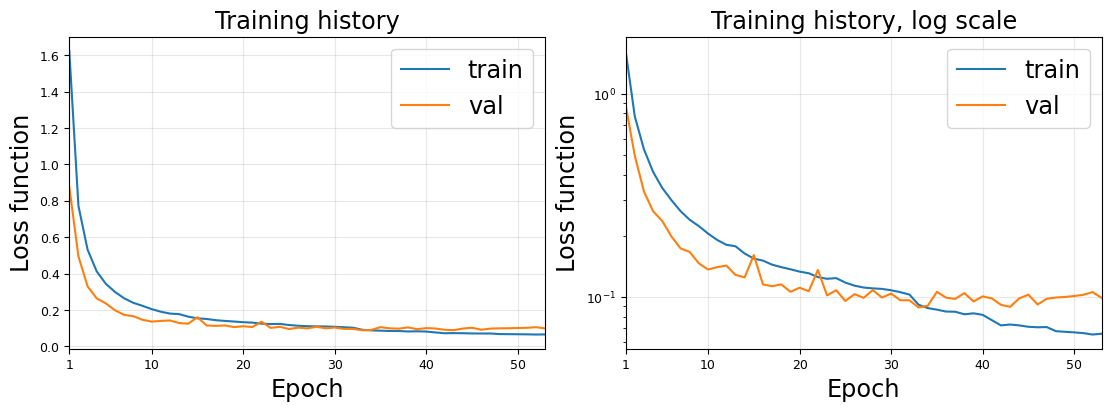

In [19]:
### %%time
importlib.reload(plf)
importlib.reload(utils)


Nepochs = 120
steps_per_epoch = math.ceil(nTrain/batchSize)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=length_aware_loss,
    metrics=[
        "mse",
        # utils.alpha_length_bias(
        #     alpha_length_scale_tf,
        #     y_mean_tf,
        #     y_std_tf
        # ),
        utils.alpha_length_mse(
            alpha_length_scale_tf,
            y_mean_tf,
            y_std_tf
        ),
        # utils.carbon_length_bias(
        #     carbon_length_scale_tf,
        #     y_mean_tf,
        #     y_std_tf
        # ),
        utils.carbon_length_mse(
            carbon_length_scale_tf,
            y_mean_tf,
            y_std_tf
        ),
    ]
)

current_time = datetime.now().strftime("%Y_%b_%d_%H_%M_%S")
print("Training start. Current Time =", current_time)
print()


model_save_dir = './training/acogdyby.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        model_save_dir,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

steps_per_epoch = nTrain // batchSize
validation_steps = nVal // batchSize

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=Nepochs,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    verbose=1,
    callbacks=callbacks
)
plf.plotTrainHistory(history)

In [5]:
# model_save_dir = './training/tpc_model.keras'
# model.save(model_save_dir)

## Model performance on training data.

Fill Pandas DataFrame with true and response values.

In [11]:
#remember to load the correct model 
model_path = './training/tpc_model.keras'
model = tf.keras.models.load_model(
    model_path,
    compile=True,
    safe_mode=False,
    custom_objects={
        "length_aware_loss": length_aware_loss,
        "alpha_length_bias": utils.alpha_length_bias,
        "alpha_length_mse": utils.alpha_length_mse,
        "carbon_length_bias": utils.carbon_length_bias,
        "carbon_length_mse": utils.carbon_length_mse,
    }
)


In [30]:
%%time
importlib.reload(utils)

rows = []

#creating a df for model performance analysis
for features, labels_norm in validation_dataset:
    model_answer_norm = model(features, training=False)

    labels = utils.denorm_y(labels_norm, y_mean_tf, y_std_tf)
    model_answer = utils.denorm_y(model_answer_norm, y_mean_tf, y_std_tf)

    batch_data = np.column_stack(
        [
            labels.numpy(),
            model_answer.numpy()
        ]
    )

    rows.append(batch_data)

data = np.vstack(rows)

df = pd.DataFrame(
    data=data,
    columns=utils.getSimRecoColumns(utils.columns_relative)
)

df.describe()

CPU times: user 24.8 s, sys: 153 ms, total: 25 s
Wall time: 19.8 s


,xVtx_sim,yVtx_sim,dxAlpha_sim,dyAlpha_sim,dzAlpha_sim,dxCarbon_sim,dyCarbon_sim,dzCarbon_sim,xVtx_reco,yVtx_reco,dxAlpha_reco,dyAlpha_reco,dzAlpha_reco,dxCarbon_reco,dyCarbon_reco,dzCarbon_reco
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000
mean,-0.545086,-0.003186,-0.069775,-0.083414,-1.812789,-0.819206,-0.029970,0.228719,0.038714,-0.015353,-0.860653,-0.631446,-1.988461,-0.736016,0.009968,0.108772
std,57.675606,1.011532,38.120556,32.155910,41.079556,5.822340,5.425517,6.337122,56.595543,0.959698,38.161949,32.687824,40.504803,5.583619,5.378956,6.128260
min,-99.975624,-3.348772,-178.119461,-89.003242,-113.052704,-17.364536,-12.181979,-16.426590,-102.177910,-2.686640,-173.614655,-90.150650,-119.043915,-16.556305,-12.443376,-16.694191
25%,-49.698822,-0.708611,-16.697304,-17.825564,-20.262112,-5.076816,-4.118637,-4.367264,-48.897383,-0.672749,-18.049853,-17.910655,-20.888246,-4.857524,-4.261669,-4.192163
50%,-3.626171,0.012546,0.405645,0.002965,-0.610512,-0.854310,-0.001051,0.275200,-1.096263,-0.010740,0.137866,-0.936098,1.504225,-0.820245,0.189395,-0.497417
75%,49.724960,0.688400,17.930142,18.189827,16.804163,3.352801,4.128130,4.993721,49.612205,0.663510,17.802900,17.956489,16.209474,3.410442,4.012855,4.812828
max,99.896530,3.026531,194.333786,90.486801,108.585297,14.288156,12.350928,16.939796,115.539383,2.731691,167.016785,90.558754,111.696960,14.762946,13.086138,16.175365


In [82]:
# df.to_csv("./dfs/df_ml.csv", index=False)
# df = pd.read_csv("./dfs/df_ml.csv")

In [31]:
#calculating track lengths
df["LAlpha_sim"] = np.sqrt(
    df["dxAlpha_sim"]**2 +
    df["dyAlpha_sim"]**2 +
    df["dzAlpha_sim"]**2
)

df["LCarbon_sim"] = np.sqrt(
    df["dxCarbon_sim"]**2 +
    df["dyCarbon_sim"]**2 +
    df["dzCarbon_sim"]**2
)

max_length_alpha = 150
max_length_carbon = 17
min_length_alpha = 0.0
max_length_alpha = 150.0


#fiducial cuts regarding the lengths of the tracks
mask = (
    (df["LCarbon_sim"] <= max_length_carbon) &
    (df["LAlpha_sim"] <= max_length_alpha)
)

df_cut = df[mask].copy()

print("Number of events before the cut", len(df))
print("After the cut:", len(df_cut))
print("Number of removed events:", len(df) - len(df_cut))

Number of events before the cut 1760
After the cut: 1728
Number of removed events: 32


In [32]:
# df.to_csv("./dfs/df_tpc.csv", index=False)
#df_cut = pd.read_csv("./dfs/df_ml_cut.csv")
df = df_cut.copy()

### Resolution plots

In [1]:
importlib.reload(plf)

#normalized target residuals
# plf.plotTargetResiduals(df, y_std, normalized=True)

#physical target residuals
plf.plotTargetResiduals(df, y_std, normalized=False)

NameError: name 'importlib' is not defined

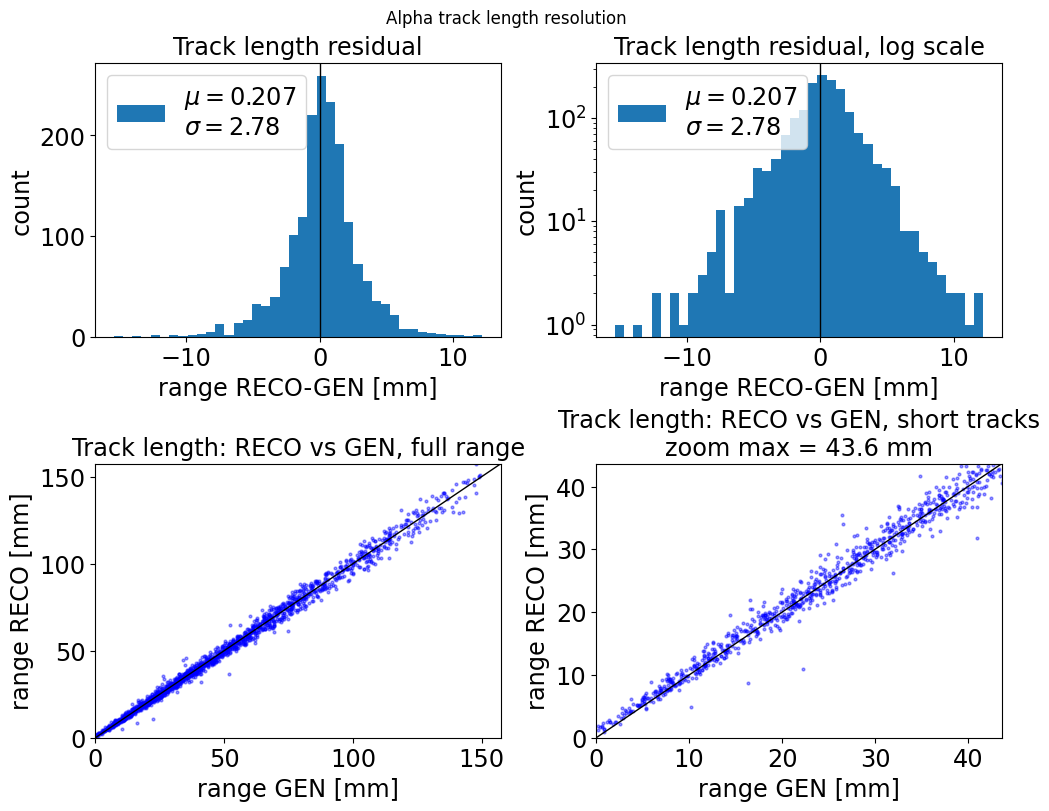

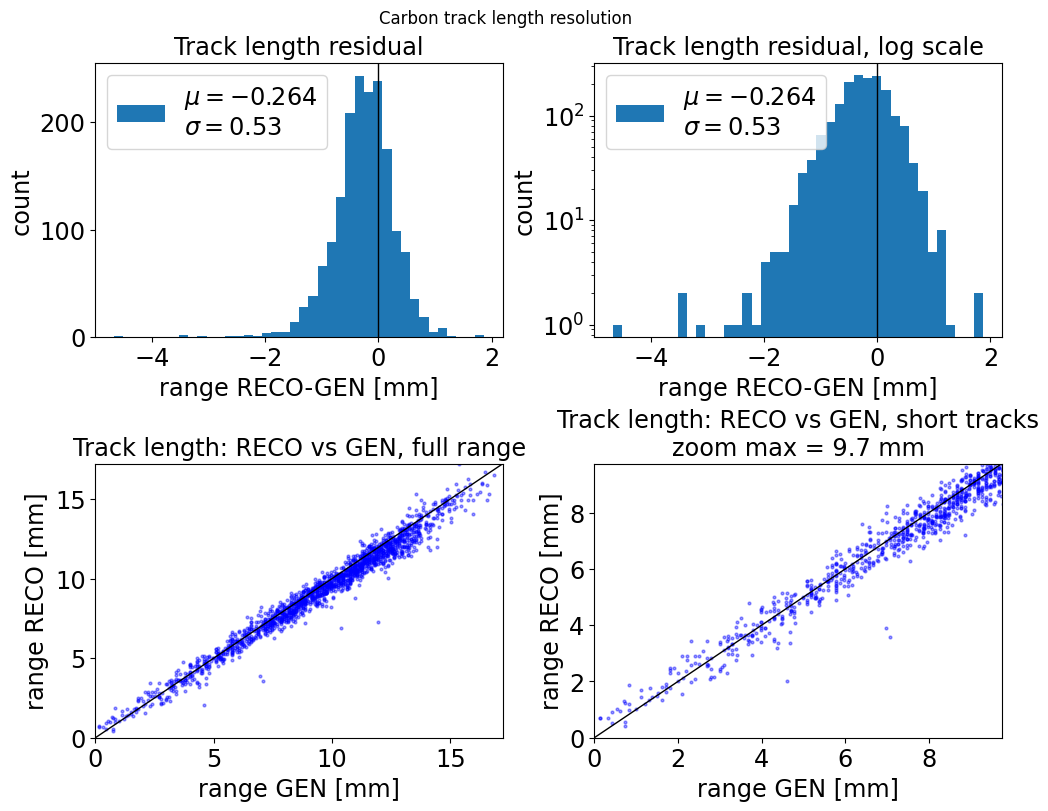

In [34]:
importlib.reload(plf)
plf.plotLengthPull(df, partName="Alpha")
plf.plotLengthPull(df, partName="Carbon")

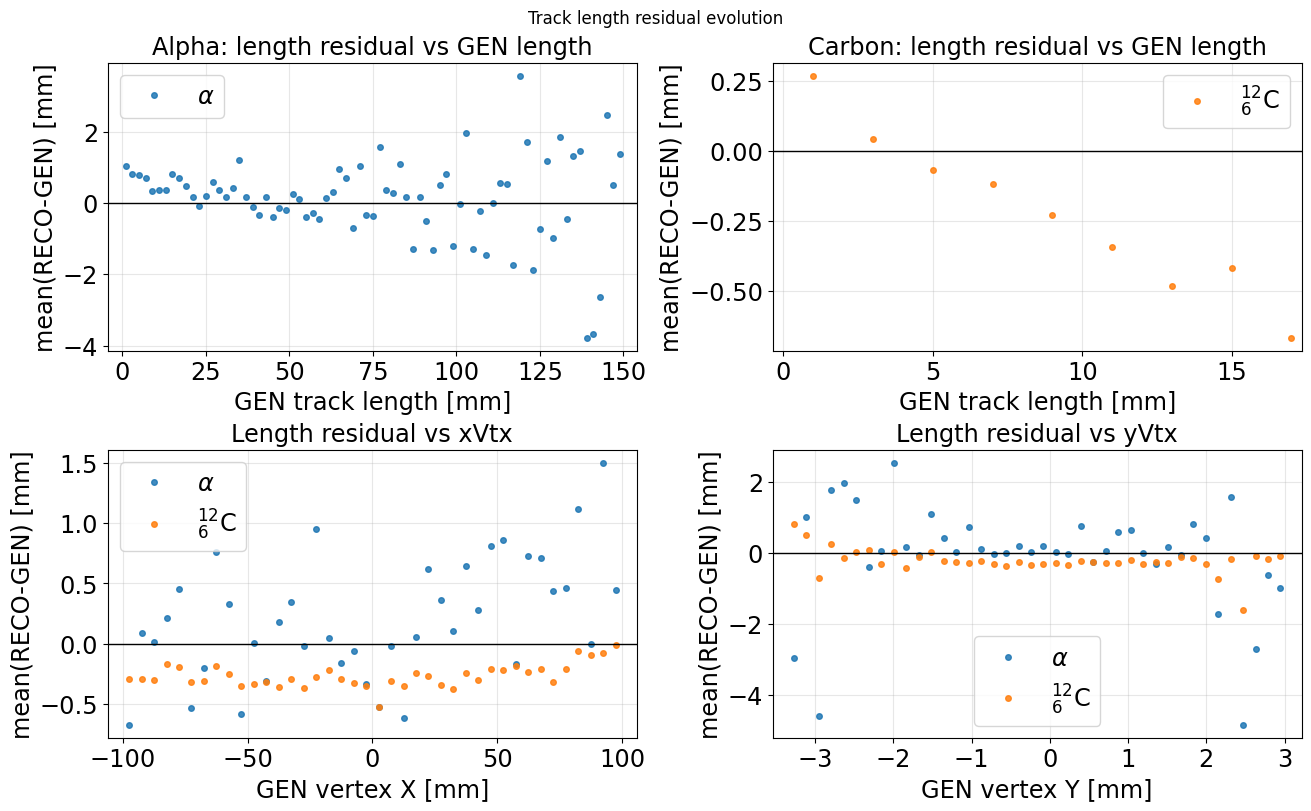

In [35]:
plf.plotLengthPullEvolution(df)

Carbon track length efficiency: 0.6117 (61.17%) [1057/1728]


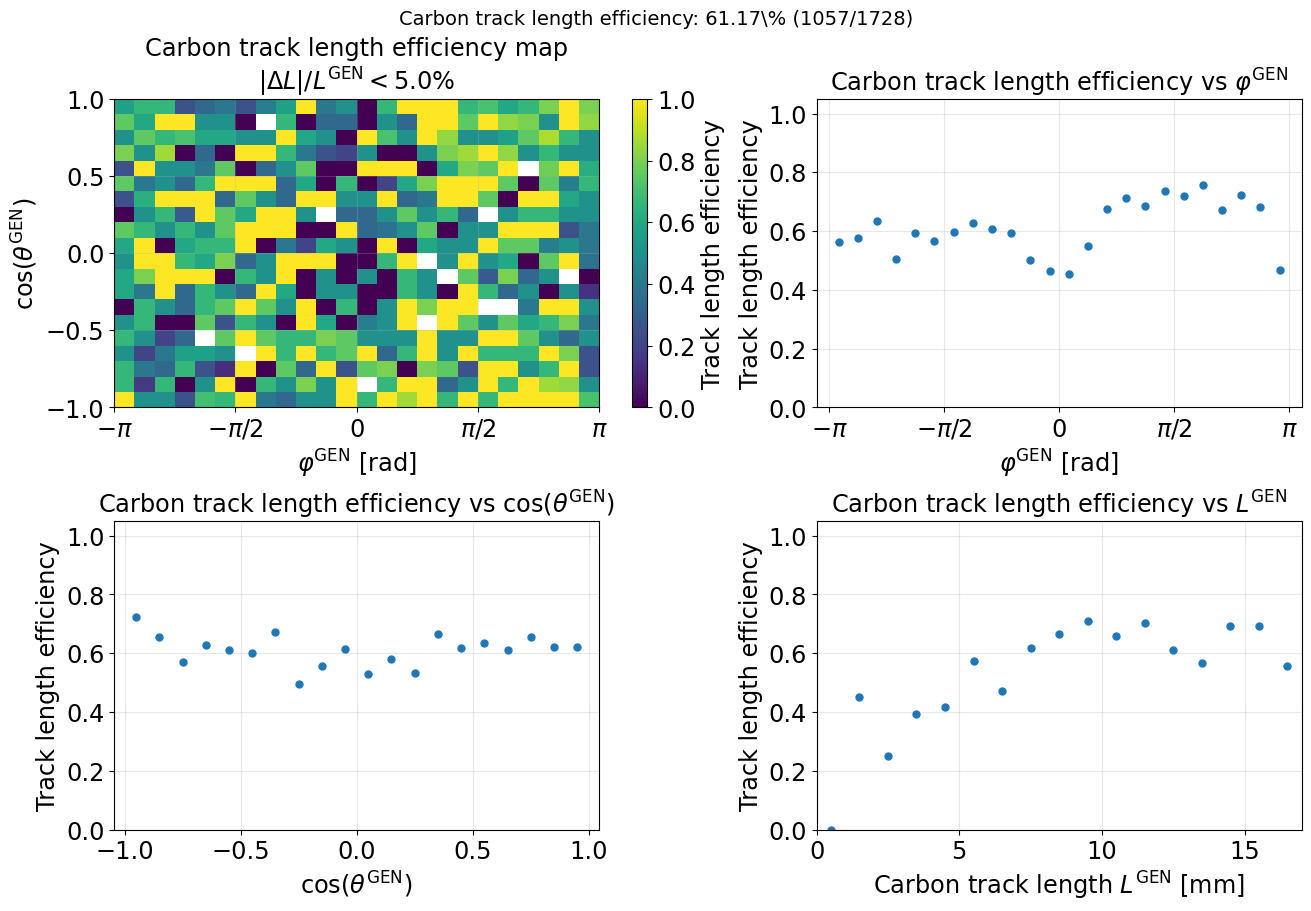

In [36]:
importlib.reload(plf)

fig, axes, df_eff, summary_carbon = plf.plotTrackLengthEffMaps(
    df,
    partName="Carbon",
    tolerance=0.05
)

Particle: Alpha
Angular tolerance: 3.0 deg
Good angular reconstructions: 680
All tracks in denominator: 1728
Mean angular efficiency: 0.3935 = 39.35%


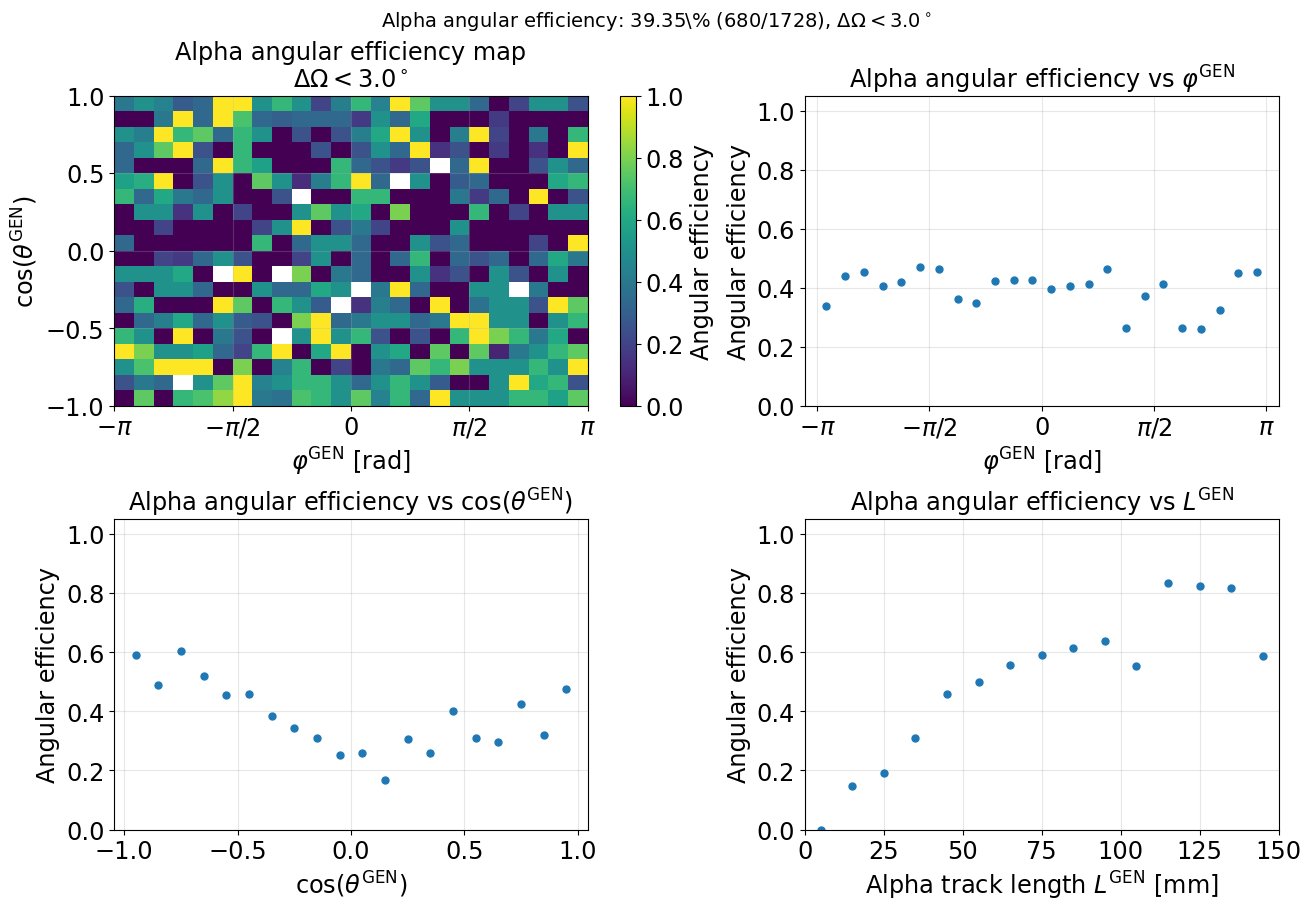

In [37]:
importlib.reload(plf)

fig, axes, df_ang_alpha, summary_alpha = plf.plotAngularEffMaps(
    df,
    partName="Alpha",
    angle_tolerance_deg=3.0
)

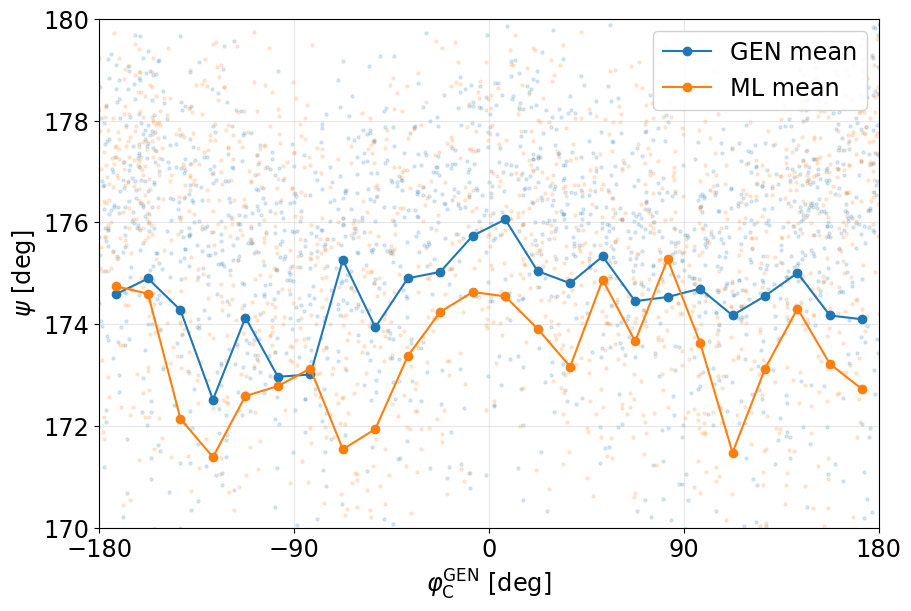

In [39]:
importlib.reload(plf)

fig, ax, opening_vs_phi_deg = plf.plotOpeningAngleVsCarbonPhiDeg(
    df,
    phi_bins=24,
    show_scatter=True,
    ylim=(170, 180)
)